# NBA pipeline


In [7]:
import os
print(os.getcwd())

/Users/ben/Project-1-Relational-Model_bengarozzo/pipeline


2026-03-30 14:47:34,270 - INFO - Starting nba_pipeline workflow
2026-03-30 14:47:34,272 - INFO - Loading file: ../data/cleaned/game_clean.csv
2026-03-30 14:47:34,563 - INFO - Loading file: ../data/cleaned/line_score_clean.csv
2026-03-30 14:47:34,714 - INFO - Loading file: ../data/cleaned/team_history_clean.csv
2026-03-30 14:47:34,716 - INFO - Loading file: ../data/cleaned/other_stats_clean.csv
2026-03-30 14:47:34,768 - INFO - Registering cleaned tables in DuckDB
2026-03-30 14:47:34,830 - INFO - Running SQL checks


Row counts by table:


,table_name,row_count
0,game,65642
1,line_score,58013
2,team_history,52
3,other_stats,28261



Season summary:


,season_type,game_count,avg_home_points,avg_away_points
0,Regular Season,60192,104.763108,101.158543
1,Playoffs,3842,103.223581,98.788652
2,Pre Season,1536,100.382161,97.528646
3,All-Star,63,129.253968,129.968254
4,All Star,9,134.666667,130.888889


...

,game_id,game_date,team_id_home,team_id_away,team_abbreviation_home,team_abbreviation_away,pts_home,pts_away,avg_pts_home,avg_reb_home,...,avg_fg3_pct_home,avg_ft_pct_home,avg_pts_away,avg_reb_away,avg_ast_away,avg_tov_away,avg_fg_pct_away,avg_fg3_pct_away,avg_ft_pct_away,home_win
0,48000053,1981-05-14,1610612745,1610612738,HOU,BOS,91.0,102.0,89.4,43.000000,...,0.266600,0.7158,98.4,49.400,22.2,17.600000,0.45800,0.133400,0.7237,0
1,28100732,1982-03-16,1610612749,1610612755,MIL,PHL,106.0,91.0,110.1,39.222222,...,0.323200,0.7781,116.7,43.500,30.2,16.285714,0.53340,0.345875,0.7360,1
2,48100028,1982-05-07,1610612749,1610612755,MIL,PHL,90.0,102.0,102.7,39.800000,...,0.507200,0.7233,107.2,40.900,26.2,15.800000,0.52130,0.154833,0.7482,0
3,48100038,1982-05-21,1610612755,1610612738,PHL,BOS,75.0,88.0,101.6,41.500000,...,0.238167,0.7444,107.6,49.875,23.5,17.500000,0.47025,0.158400,0.7422,0
4,48100039,1982-05-23,1610612738,1610612755,BOS,PHL,106.0,120.0,105.5,51.250000,...,0.158400,0.7411,97.1,41.700,24.8,17.700000,0.46550,0.204143,0.7341,0


2026-03-30 14:47:35,688 - INFO - Training model



Target distribution:
home_win
1    27980
0    18343
Name: count, dtype: int64


2026-03-30 14:47:37,659 - INFO - Accuracy: 0.6204
2026-03-30 14:47:37,660 - INFO - Confusion matrix:
[[1066 2666]
 [ 851 4682]]
2026-03-30 14:47:37,740 - INFO - Plotting accuracy summary chart


Accuracy: 0.6203993524015111

Confusion Matrix:
 [[1066 2666]
 [ 851 4682]]


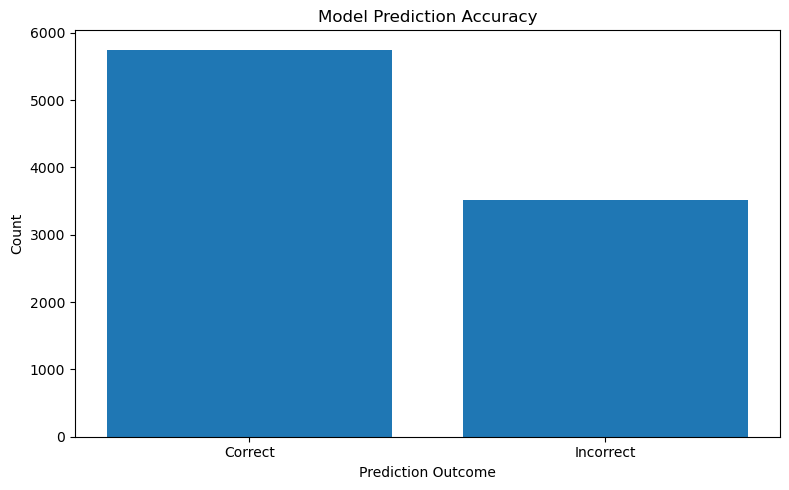

2026-03-30 14:47:37,918 - INFO - Plotting confidence vs accuracy chart
/var/folders/x0/h9dp0lbj0r9b1qrgp82_d9jw0000gn/T/ipykernel_27028/2735312328.py:278: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_by_bin = df_plot.groupby("bin", observed=False).apply(


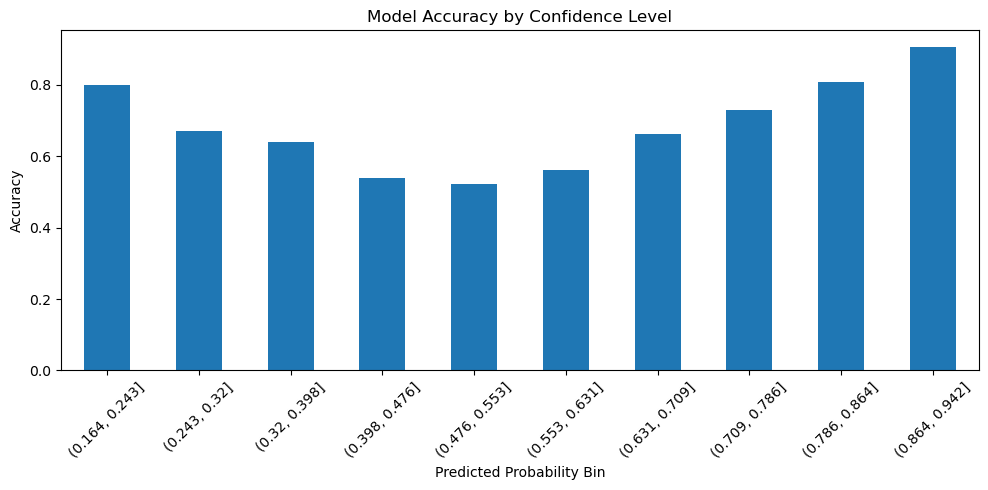

2026-03-30 14:47:38,422 - INFO - Plotting feature importance chart


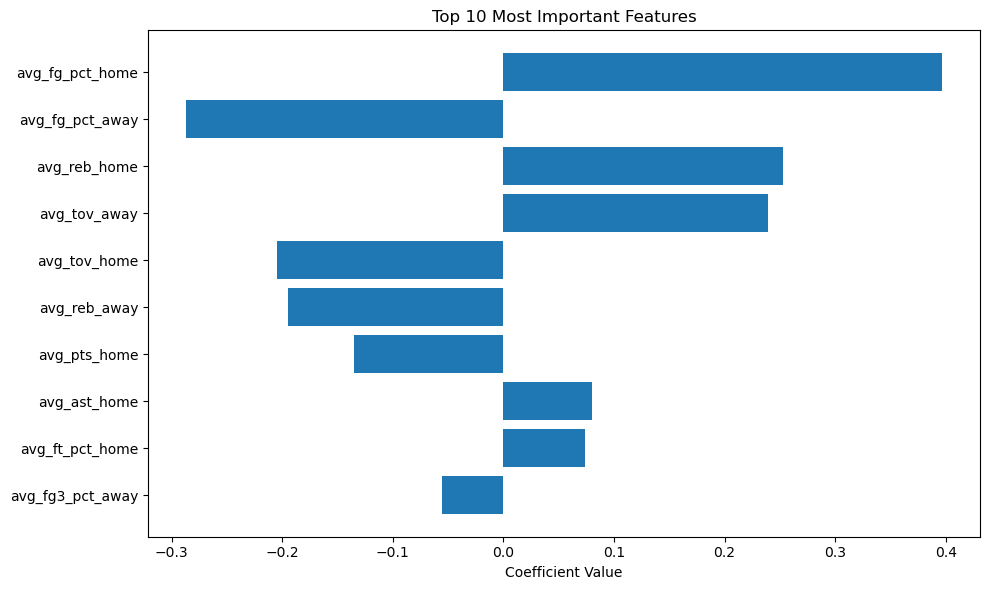

2026-03-30 14:47:38,810 - INFO - nba_pipeline workflow completed successfully


In [23]:
import logging
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ============================================================
# Logging setup
# ============================================================

Path("../logs").mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("../logs/pipeline.log"),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger(__name__)


# ============================================================
# File paths
# ============================================================

CLEAN_DATA_DIR = Path("../data/cleaned")

GAME_PATH = CLEAN_DATA_DIR / "game_clean.csv"
LINE_SCORE_PATH = CLEAN_DATA_DIR / "line_score_clean.csv"
TEAM_HISTORY_PATH = CLEAN_DATA_DIR / "team_history_clean.csv"
OTHER_STATS_PATH = CLEAN_DATA_DIR / "other_stats_clean.csv"


# ============================================================
# Helper functions
# ============================================================

def load_csv_file(file_path: Path) -> pd.DataFrame:
    """
    Load a CSV file into a pandas DataFrame.
    """
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required file: {file_path}")

    logger.info("Loading file: %s", file_path)
    return pd.read_csv(file_path)


def setup_duckdb_connection(
    game: pd.DataFrame,
    line_score: pd.DataFrame,
    team_history: pd.DataFrame,
    other_stats: pd.DataFrame
) -> duckdb.DuckDBPyConnection:
    """
    Register cleaned tables in DuckDB.
    """
    logger.info("Registering cleaned tables in DuckDB")
    con = duckdb.connect()
    con.register("game", game)
    con.register("line_score", line_score)
    con.register("team_history", team_history)
    con.register("other_stats", other_stats)
    return con


def run_sql_checks(con: duckdb.DuckDBPyConnection) -> None:
    """
    Run a few SQL queries to demonstrate data preparation and validation.
    """
    logger.info("Running SQL checks")

    row_counts = con.execute("""
        SELECT 'game' AS table_name, COUNT(*) AS row_count FROM game
        UNION ALL
        SELECT 'line_score' AS table_name, COUNT(*) AS row_count FROM line_score
        UNION ALL
        SELECT 'team_history' AS table_name, COUNT(*) AS row_count FROM team_history
        UNION ALL
        SELECT 'other_stats' AS table_name, COUNT(*) AS row_count FROM other_stats
    """).df()

    print("Row counts by table:")
    display(row_counts)

    season_summary = con.execute("""
        SELECT
            season_type,
            COUNT(*) AS game_count,
            AVG(pts_home) AS avg_home_points,
            AVG(pts_away) AS avg_away_points
        FROM game
        GROUP BY season_type
        ORDER BY game_count DESC
    """).df()

    print("\nSeason summary:")
    display(season_summary)

    join_check = con.execute("""
        SELECT COUNT(*) AS matched_games
        FROM game g
        INNER JOIN other_stats o
            ON g.game_id = o.game_id
    """).df()

    print("\nJoin check between game and other_stats:")
    display(join_check)


def build_modeling_dataset(game: pd.DataFrame) -> pd.DataFrame:
    """
    Create a game-level modeling dataset using rolling averages from prior games only.
    """
    logger.info("Building modeling dataset")

    game_model = game.copy()
    game_model["game_date"] = pd.to_datetime(game_model["game_date"], errors="coerce")
    game_model = game_model.dropna(subset=["game_date"]).sort_values("game_date").reset_index(drop=True)

    # Remove All-Star / exhibition-style team abbreviations.
    game_model = game_model[
        ~game_model["team_abbreviation_home"].isin(["WST", "EST"])
        & ~game_model["team_abbreviation_away"].isin(["WST", "EST"])
    ].copy()

    home_cols = [
        "game_id", "game_date", "team_id_home",
        "pts_home", "reb_home", "ast_home", "tov_home",
        "fg_pct_home", "fg3_pct_home", "ft_pct_home"
    ]

    away_cols = [
        "game_id", "game_date", "team_id_away",
        "pts_away", "reb_away", "ast_away", "tov_away",
        "fg_pct_away", "fg3_pct_away", "ft_pct_away"
    ]

    home = game_model[home_cols].copy()
    home.columns = [
        "game_id", "game_date", "team_id",
        "pts", "reb", "ast", "tov",
        "fg_pct", "fg3_pct", "ft_pct"
    ]
    home["is_home"] = 1

    away = game_model[away_cols].copy()
    away.columns = [
        "game_id", "game_date", "team_id",
        "pts", "reb", "ast", "tov",
        "fg_pct", "fg3_pct", "ft_pct"
    ]
    away["is_home"] = 0

    long_df = pd.concat([home, away], ignore_index=True)
    long_df = long_df.sort_values(["team_id", "game_date"]).reset_index(drop=True)

    stats = ["pts", "reb", "ast", "tov", "fg_pct", "fg3_pct", "ft_pct"]

    for stat in stats:
        long_df[f"avg_{stat}"] = (
            long_df.groupby("team_id")[stat]
            .transform(lambda s: s.shift(1).rolling(window=10, min_periods=5).mean())
        )

    home_features = long_df[long_df["is_home"] == 1][
        ["game_id"] + [f"avg_{stat}" for stat in stats]
    ].copy()

    away_features = long_df[long_df["is_home"] == 0][
        ["game_id"] + [f"avg_{stat}" for stat in stats]
    ].copy()

    model_df = game_model[[
        "game_id", "game_date", "team_id_home", "team_id_away",
        "team_abbreviation_home", "team_abbreviation_away",
        "pts_home", "pts_away"
    ]].copy()

    model_df = model_df.merge(home_features, on="game_id", how="left")
    model_df = model_df.merge(
        away_features,
        on="game_id",
        how="left",
        suffixes=("_home", "_away")
    )

    model_df["home_win"] = (model_df["pts_home"] > model_df["pts_away"]).astype(int)
    model_df = model_df.dropna().reset_index(drop=True)

    logger.info("Modeling dataset shape: %s", model_df.shape)
    return model_df


def train_and_evaluate_model(model_df: pd.DataFrame):
    """
    Train a scaled logistic regression model and evaluate test performance.
    """
    logger.info("Training model")

    X = model_df.drop(columns=[
        "game_id", "game_date",
        "team_id_home", "team_id_away",
        "team_abbreviation_home", "team_abbreviation_away",
        "pts_home", "pts_away",
        "home_win"
    ])

    y = model_df["home_win"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    logger.info("Accuracy: %.4f", accuracy)
    logger.info("Confusion matrix:\n%s", cm)

    print("Accuracy:", accuracy)
    print("\nConfusion Matrix:\n", cm)

    return model, X, X_test, y_test, y_pred, y_prob


def plot_prediction_accuracy(y_test: pd.Series, y_pred: np.ndarray) -> None:
    """
    Plot counts of correct and incorrect predictions.
    """
    logger.info("Plotting accuracy summary chart")

    correct = (y_test == y_pred).sum()
    incorrect = (y_test != y_pred).sum()

    plt.figure(figsize=(8, 5))
    plt.bar(["Correct", "Incorrect"], [correct, incorrect])
    plt.title("Model Prediction Accuracy")
    plt.xlabel("Prediction Outcome")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_confidence_accuracy(y_test: pd.Series, y_pred: np.ndarray, y_prob: np.ndarray) -> None:
    """
    Plot model accuracy by predicted probability bin.
    """
    logger.info("Plotting confidence vs accuracy chart")

    df_plot = pd.DataFrame({
        "prob": y_prob,
        "actual": y_test.values,
        "pred": y_pred
    })

    df_plot["bin"] = pd.cut(df_plot["prob"], bins=10)
    accuracy_by_bin = df_plot.groupby("bin", observed=False).apply(
        lambda x: (x["actual"] == x["pred"]).mean()
    )

    plt.figure(figsize=(10, 5))
    accuracy_by_bin.plot(kind="bar")
    plt.title("Model Accuracy by Confidence Level")
    plt.xlabel("Predicted Probability Bin")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model: Pipeline, X: pd.DataFrame) -> None:
    """
    Plot the top 10 most influential logistic regression coefficients.
    """
    logger.info("Plotting feature importance chart")

    coef = model.named_steps["logreg"].coef_[0]
    coef_df = pd.DataFrame({
        "feature": X.columns,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values("abs_coef", ascending=False).head(10)

    coef_df = coef_df.sort_values("abs_coef", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(coef_df["feature"], coef_df["coef"])
    plt.title("Top 10 Most Important Features")
    plt.xlabel("Coefficient Value")
    plt.tight_layout()
    plt.show()


# ============================================================
# Main pipeline
# ============================================================

try:
    logger.info("Starting nba_pipeline workflow")

    # Load cleaned tables only.
    game = load_csv_file(GAME_PATH)
    line_score = load_csv_file(LINE_SCORE_PATH)
    team_history = load_csv_file(TEAM_HISTORY_PATH)
    other_stats = load_csv_file(OTHER_STATS_PATH)

    # Register tables in DuckDB and run required SQL checks.
    con = setup_duckdb_connection(game, line_score, team_history, other_stats)
    run_sql_checks(con)

    # Build the final pre-game modeling dataset.
    model_df = build_modeling_dataset(game)

    print("\nModeling dataset preview:")
    display(model_df.head())

    print("\nTarget distribution:")
    print(model_df["home_win"].value_counts())

    # Train and evaluate model.
    model, X, X_test, y_test, y_pred, y_prob = train_and_evaluate_model(model_df)

    # Create required visualizations.
    plot_prediction_accuracy(y_test, y_pred)
    plot_confidence_accuracy(y_test, y_pred, y_prob)
    plot_feature_importance(model, X)

    logger.info("nba_pipeline workflow completed successfully")

except FileNotFoundError as e:
    logger.error("File path error: %s", e)
    print(f"File path error: {e}")

except pd.errors.ParserError as e:
    logger.error("CSV parsing error: %s", e)
    print(f"CSV parsing error: {e}")

except duckdb.Error as e:
    logger.error("DuckDB error: %s", e)
    print(f"DuckDB error: {e}")

except Exception as e:
    logger.exception("Unexpected pipeline error")
    print(f"Unexpected error: {e}")

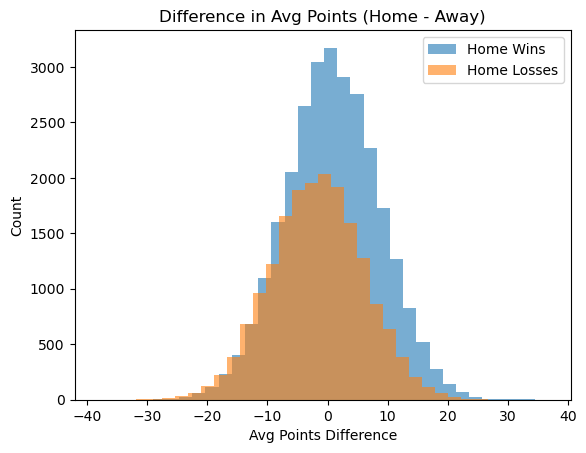

In [21]:
model_df["pts_diff"] = model_df["avg_pts_home"] - model_df["avg_pts_away"]

plt.figure()

plt.hist(
    model_df[model_df["home_win"] == 1]["pts_diff"],
    bins=30,
    alpha=0.6,
    label="Home Wins"
)

plt.hist(
    model_df[model_df["home_win"] == 0]["pts_diff"],
    bins=30,
    alpha=0.6,
    label="Home Losses"
)

plt.legend()
plt.title("Difference in Avg Points (Home - Away)")
plt.xlabel("Avg Points Difference")
plt.ylabel("Count")

plt.show()

## Analysis of Model Results and Visualizations

### Overall Model Performance

The model achieves an accuracy of approximately 62%, indicating that prior team performance statistics provide meaningful predictive power for NBA game outcomes. While this is significantly better than random guessing (50%), the model still makes a substantial number of incorrect predictions, reflecting the inherent uncertainty and variability in sports outcomes.

---

### Model Accuracy by Confidence Level

The model demonstrates strong calibration, as prediction accuracy increases with higher confidence levels. Predictions with probabilities near 0.5 have the lowest accuracy, while predictions with probabilities closer to 0 or 1 are significantly more accurate. 

This suggests that the model is not only making predictions but also providing reliable estimates of uncertainty. In practice, this means the model is most useful when it is confident, and less reliable when it is uncertain.

---

### Feature Importance

The feature importance analysis shows that field goal percentage is the most influential factor in predicting game outcomes. Specifically, higher average field goal percentage for the home team increases the likelihood of winning, while higher field goal percentage for the away team decreases it.

Rebounding and turnovers also play important roles, indicating that both possession control and scoring efficiency are key drivers of success. These findings align with established basketball analytics principles, particularly the "Four Factors" framework, which emphasizes shooting efficiency, turnovers, rebounding, and free throws.

---

### Difference in Average Points (Home vs Away)

The distribution of average points difference shows a clear relationship between team strength and game outcomes. When the home team has a higher prior scoring average than the away team, the likelihood of winning increases. Conversely, when the home team has a lower scoring average, losses are more common.

However, there is substantial overlap between the distributions of wins and losses, indicating that scoring ability alone does not fully determine game outcomes. This overlap highlights the role of randomness and other unobserved factors in sports performance.

---

### Summary

Overall, the analysis demonstrates that historical team performance metrics can be used to predict NBA game outcomes with moderate success. The model captures key drivers of winning, such as shooting efficiency and rebounding, while also reflecting the uncertainty inherent in competitive sports. These results suggest that while data-driven approaches can provide valuable insights, they cannot fully eliminate unpredictability in game outcomes.